# Exercise: Exploring the Iris Data

In this notebook you will independently apply everything from `01_intro_to_pandas.ipynb` and `03_plotting.ipynb` to a new dataset. The **Iris dataset** is one of the most widely used datasets in data science, it contains measurements (in centimetres) of 150 iris flowers across three species. Your goal is to load it, explore it, answer questions with code, and visualise your findings.

---

![Iris species](../assets/iris.png)

---

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part 1: Exploring the Data

### Challenge 1: Preview and inspect

Display the first 5 rows and the last 10 rows of the DataFrame.

In [2]:
# Preview the first five rows and last ten rows
display(df.head())
display(df.tail(10))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Challenge 2: How many irises are in the dataset?

How many rows and columns does the DataFrame have?

In [5]:
# DataFrame dimensions: (rows, columns)
df.shape

(150, 5)

### Challenge 3: How many species are there?

Find out how many distinct species exist in the dataset, and what they are called.

In [6]:
# Number of distinct species and their names
print(f"Number of species: {df['species'].nunique()}")
df["species"].unique()

Number of species: 3


<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

---

## Part 2: Statistics

### Challenge 4: Descriptive statistics for petal length

Calculate the mean, median, and mode for `petal_length`. What can you conclude about the distribution?

In [7]:
# Mean, median, and all modes of petal length
petal_length = df["petal_length"]
print(f"Mean: {petal_length.mean():.3f}")
print(f"Median: {petal_length.median():.3f}")
print("Mode(s):")
display(petal_length.mode())
print("The overall distribution is multimodal because it combines three species with different petal lengths.")

Mean: 3.759
Median: 4.350
Mode(s):


0    1.5
Name: petal_length, dtype: float64

The overall distribution is multimodal because it combines three species with different petal lengths.


### Challenge 5: Range and spread

What is the smallest and largest value for `petal_length`? Calculate the variance and standard deviation.

In [8]:
# Minimum, maximum, sample variance, and sample standard deviation
petal_length = df["petal_length"]
print(f"Minimum: {petal_length.min():.2f}")
print(f"Maximum: {petal_length.max():.2f}")
print(f"Variance: {petal_length.var():.3f}")
print(f"Standard deviation: {petal_length.std():.3f}")

Minimum: 1.00
Maximum: 6.90
Variance: 3.113
Standard deviation: 1.764


### Challenge 6: Full summary

Use a single command to get the basic descriptive statistics for all columns.

In [9]:
# Basic descriptive statistics for every column, including species
df.describe(include="all")

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


### Challenge 7: Overall average sepal length

What is the average `sepal_length` across all 150 flowers?

In [10]:
# Average sepal length across all flowers
df["sepal_length"].mean()

np.float64(5.843333333333334)

---

## Part 3: Groupby

### Challenge 8: Count by species

Use `groupby` to count the number of observations for each species.

In [11]:
# Number of observations for each species
df.groupby("species").size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

### Challenge 9: Average measurements by species

Use `groupby` to find the average `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` for each species.

In [12]:
# Average of each measurement grouped by species
df.groupby("species")[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


---

## Part 4: Column Operations and Filtering

### Challenge 10: Add a new column

Create a new column `sepal_total` that is the sum of `sepal_width` and `sepal_length`.

In [13]:
# Total sepal measurement per flower
df["sepal_total"] = df["sepal_width"] + df["sepal_length"]
df[["sepal_length", "sepal_width", "sepal_total"]].head()

,sepal_length,sepal_width,sepal_total
0,5.1,3.5,8.6
1,4.9,3.0,7.9
2,4.7,3.2,7.9
3,4.6,3.1,7.7
4,5.0,3.6,8.6


### Challenge 11: Add petal area

Create a new column `petal_area` as a rough estimate of petal area: `petal_length × petal_width`.

In [14]:
# Rough petal area estimate in square centimetres
df["petal_area"] = df["petal_length"] * df["petal_width"]
df[["petal_length", "petal_width", "petal_area"]].head()

,petal_length,petal_width,petal_area
0,1.4,0.2,0.28
1,1.4,0.2,0.28
2,1.3,0.2,0.26
3,1.5,0.2,0.30
4,1.4,0.2,0.28


### Challenge 12: Filter by petal area

Create a new DataFrame containing only the flowers where `petal_area` is greater than 1 cm².

In [15]:
# Keep flowers with estimated petal area greater than 1 cm^2
large_petals = df.loc[df["petal_area"] > 1].copy()
print(f"Flowers with petal area > 1 cm^2: {len(large_petals)}")
large_petals.head()

Flowers with petal area > 1 cm^2: 100


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


### Challenge 13: Split by species

Create three separate DataFrames, one for each species, using the full dataset.

In [16]:
# Split the full dataset into one DataFrame per species
setosa = df.loc[df["species"] == "Iris-setosa"].copy()
versicolor = df.loc[df["species"] == "Iris-versicolor"].copy()
virginica = df.loc[df["species"] == "Iris-virginica"].copy()

print(f"setosa: {setosa.shape}")
print(f"versicolor: {versicolor.shape}")
print(f"virginica: {virginica.shape}")

setosa: (50, 7)
versicolor: (50, 7)
virginica: (50, 7)


---

## Part 5: Visualisation

### Challenge 14: Histogram of petal length

Create a histogram of `petal_length`. Describe the distribution, is it symmetric, skewed, or does it appear to have multiple peaks?

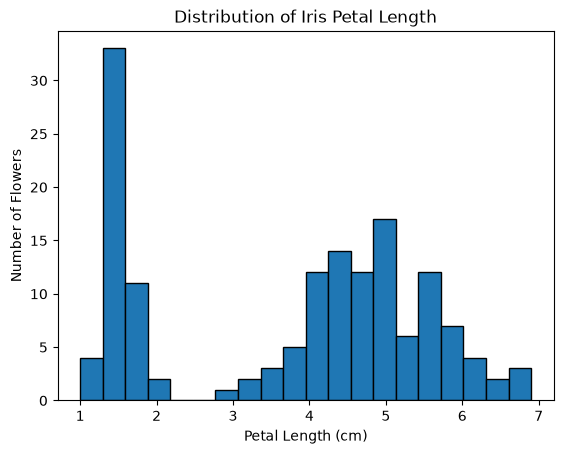

The distribution is multimodal, with a distinct short-petal group and longer-petal groups from the other species.


In [3]:
# Histogram of petal length
df["petal_length"].plot(kind="hist", bins=20, edgecolor="black", title="Distribution of Iris Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Number of Flowers")
plt.show()

print("The distribution is multimodal, with a distinct short-petal group and longer-petal groups from the other species.")

### Challenge 15: Scatter matrix of petal dimensions

Create a scatter plot of `petal_length` vs `petal_width`. Do larger petals tend to be longer as well?

> Bonus: use `pd.plotting.scatter_matrix(df)` to see all pairwise relationships at once.

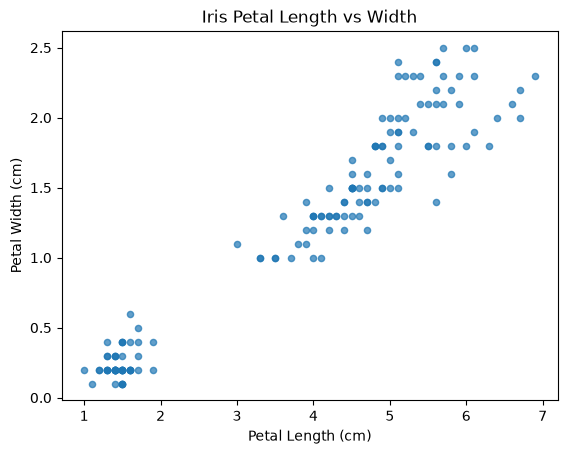

Pearson correlation: 0.963; larger petals tend to be longer and wider.


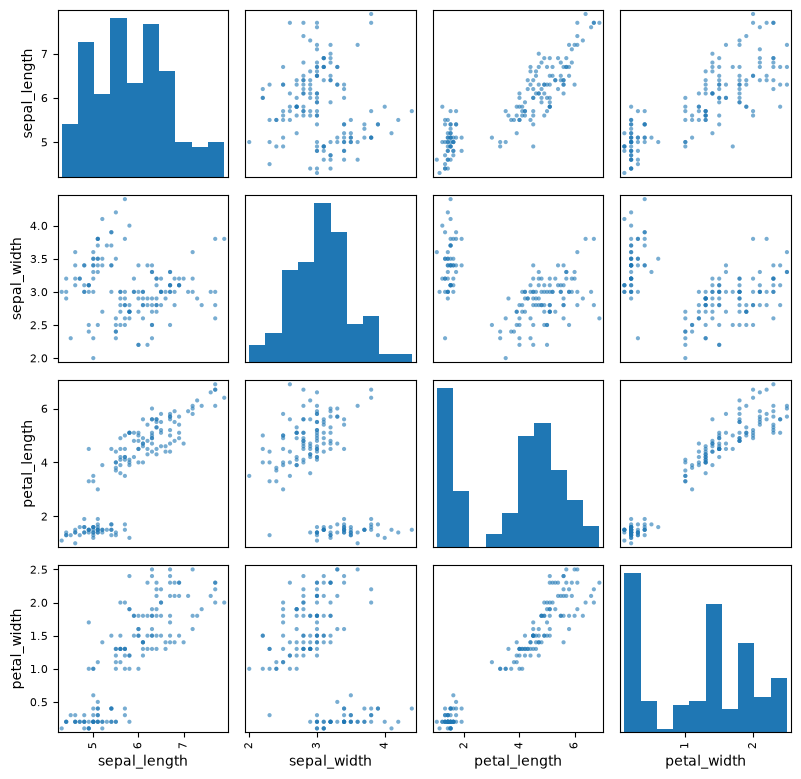

In [4]:
# Petal length versus petal width
ax = df.plot(
    kind="scatter",
    x="petal_length",
    y="petal_width",
    title="Iris Petal Length vs Width",
    alpha=0.7,
)
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
plt.show()

correlation = df["petal_length"].corr(df["petal_width"])
print(f"Pearson correlation: {correlation:.3f}; larger petals tend to be longer and wider.")

# Bonus: pairwise relationships among numeric measurements
pd.plotting.scatter_matrix(
    df.select_dtypes(include="number"),
    figsize=(8, 8),
    diagonal="hist",
    alpha=0.6,
)
plt.tight_layout()
plt.show()